In [1]:
# @title Install

# !pip uninstall -y tensorflow jax jaxlib

# !pip install pytorch-ignite
# !pip install ipynbname
# !pip install lightning
# !pip install torch_tb_profiler
# !pip install colormaps
# !pip install captum

In [2]:
# @title Importing

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import schedule
import torchmetrics
from ignite.engine import Events
from ignite.metrics import Metric, Loss
from ignite.handlers import global_step_from_engine, EarlyStopping
from torch.optim.lr_scheduler import _LRScheduler, ReduceLROnPlateau, CosineAnnealingWarmRestarts, ChainedScheduler
from ignite.contrib.handlers import TensorboardLogger
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.exceptions import NotComputableError

import lightning as L
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, ModelSummary
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.profilers import SimpleProfiler, PyTorchProfiler
from lightning.pytorch.utilities.warnings import PossibleUserWarning

from torch.optim.lr_scheduler import SequentialLR

from captum.attr import Saliency, IntegratedGradients, Occlusion, GradientShap, ShapleyValueSampling, ShapleyValues, FeatureAblation, FeaturePermutation

import shap

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, FastICA

import statsmodels.api as sm
from statsmodels.multivariate.factor_rotation import promax
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib import colors
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import colormaps as cmaps
import plotly.graph_objects as go

from tqdm.auto import tqdm

import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_rel, ttest_1samp
import scipy.io as sio
from scipy.interpolate import griddata

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import datetime
import time
import os
import sys
import glob
import ipynbname
import pickle
import json
import math
import warnings
import copy
import logging

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)
rng = np.random.default_rng(seed)

torch.set_float32_matmul_precision("high")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\A\miniconda3\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
C:\Users\A\AppData\Local\Temp\ipykernel_12056\1107270319.py:17: DeprecationWarning: c:\Users\A\miniconda3\lib\site-packages\ignite\contrib\handlers\tensorboard_logger.py has been moved to /ignite/handlers/tensorboard_logger.py and will be removed in version 0.6.0.
 Please refer to the documentation for more details.
  from ignite.contrib.handlers.tensorboard_logger import *


In [3]:
# @title Configuration

class DotDict(dict):
    def __init__(self, d=None):
        super().__init__()
        if d:
            for k, v in d.items():
                self[k] = self._wrap(v)

    def _wrap(self, value):
        if isinstance(value, dict):
            return DotDict(value)
        if isinstance(value, list):
            return [self._wrap(v) for v in value]
        return value

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = self._wrap(value)

    def __delattr__(self, name):
        try:
            del self[name]
        except KeyError:
            raise AttributeError(name)

    def to_dict(self):
        out = {}
        for k, v in self.items():
            if isinstance(v, DotDict):
                out[k] = v.to_dict()
            elif isinstance(v, list):
                out[k] = [x.to_dict() if isinstance(x, DotDict) else x for x in v]
            else:
                out[k] = v
        return out

    def __deepcopy__(self, memo):
        return DotDict(copy.deepcopy(self.to_dict(), memo))


Conf = DotDict({
    "run_id": 1,
    "paths": {
        "data": "data.mat",
        "logs": "/lightning_logs",
    },
    "session_idx": 18,
    "device": device,
    "training": {
        "batch_size": 32,
        "max_epoch": 500,
        "min_delta": 1e-4,
        "patience": 10,
    },
    "model_type": {
        "name": "mean",
        "mean": {
            "n_hidden": 16,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
        "cov": {
            "n_latent": 64,
            "n_hidden": 8,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
    },
    "optimization": {
        "optimizer_type": {
            "name": "Adam",
            "Adam": {
                "lr": 0.01,
                "weight_decay": 0,
            },
            "AdamW": {
                "lr": 0.01,
                "weight_decay": 0,
            },
        },
        "scheduler_type": {
            "name": "Reduce",
            "Reduce": {
                "factor": 0.5,
                "patience":5,
                "min_lr": 1e-10,
            },
            "Cosine": {
                "T_mult": 1,
                "eta_min": 1e-5,
                "last_epoch": -1,
            }
        }
    }
})

In [4]:
# @title Model

class Model(nn.Module):
    def __init__(self, Conf=None, **kwargs):
        super().__init__()
        self.n_position_vars = Conf.data.n_position_vars
        self.n_dense_vars = Conf.data.n_dense_vars
        self.n_sparse_vars = Conf.data.n_sparse_vars
        self.n_vars = Conf.data.n_vars
        self.n_bins = Conf.data.n_bins
        self.n_units = Conf.data.n_units
        self.device = Conf.device


class Time2Vec(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.randn(1))
        self.w = nn.Parameter(torch.randn(n_hidden - 1))
        self.b = nn.Parameter(torch.randn(n_hidden - 1))

    def forward(self, t):
        t = t.unsqueeze(-1)
        linear = self.w0 * t + self.b0
        periodic = torch.sin(self.w * t + self.b)
        return torch.cat([linear, periodic], dim=-1)


class Time2VecPositionalEncoding(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        self.t2v = Time2Vec(n_hidden)

    def forward(self, n_bins, device):
        t = torch.arange(n_bins, device=device).float()
        enc = self.t2v(t)
        return enc.unsqueeze(0)


class Transformer():
    def __init__(self, Conf=None, **kwargs):
        super().__init__(Conf=Conf, **kwargs)
        self.n_hidden = Conf.model_type[Conf.model_type.name].n_hidden
        self.n_heads = Conf.model_type[Conf.model_type.name].n_heads
        self.n_layers = Conf.model_type[Conf.model_type.name].n_layers
        self.nonlinearity = Conf.model_type[Conf.model_type.name].nonlinearity
        self.dropout = Conf.model_type[Conf.model_type.name].dropout

        self.vars_proj = nn.Linear(self.n_vars, self.n_hidden)
        
        self.positional_encoding = Time2VecPositionalEncoding(self.n_hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.n_hidden,
            nhead=self.n_heads,
            dim_feedforward=self.n_hidden * 4,
            dropout=self.dropout,
            activation=self.nonlinearity,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.n_layers)
        self.dropout_layer = nn.Dropout(self.dropout)
        

    def forward_transformer(self, x):
        x_position_vars, x_dense_vars, x_sparse_vars = x
        
        dense_vars = x_dense_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        sparse_vars = x_sparse_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        stacked = torch.cat([x_position_vars, dense_vars, sparse_vars], dim=2)
        stacked = self.vars_proj(stacked)
        
        pos_enc = self.positional_encoding(self.n_bins, stacked.device)
        combined = stacked + pos_enc
        transformed = self.transformer_encoder(combined)
        transformed = self.dropout_layer(transformed)
        return transformed


class MeanModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)


class ZeroMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batchsize = x[0].size(0)
        return torch.zeros(batchsize, self.nbins, self.nunits, device=x[0].device, dtype=x[0].dtype)


class BaselineMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.theta = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            nn.init.normal_(self.theta, mean=0, std=1e-1)
            
    def forward(self, x):
        batch_size = x[0].size(0)
        mean = self.theta
        return mean.view(1, self.n_bins, self.n_units).expand(batch_size, -1, -1)


class ConditionalMeanModel(Transformer, MeanModel):
    def __init__(self, Conf):
        Conf_ = copy.deepcopy(Conf)
        Conf_.model_type.name = "mean"
        super().__init__(Conf=Conf_)

        self.output_size = self.n_units
        self.head = nn.Linear(self.n_hidden, self.output_size)

    def forward(self, x):
        transformed = self.forward_transformer(x)
        mean = self.head(transformed)
        return mean
             

class CovModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.n_latent = Conf.model_type.cov.n_latent
        
        self.register_buffer("I", torch.eye(self.n_bins * self.n_units, dtype=torch.float32, device=self.device))
        self.length_scales = nn.Parameter(torch.empty(self.n_latent, device=self.device))
        self.noise = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            ls0 = math.log(math.expm1(0.5))
            self.length_scales.fill_(ls0)
            nn.init.normal_(self.length_scales, mean=ls0, std=1)
            nn.init.normal_(self.noise, mean=-20.0, std=1)

    def kernel(self, fun, n_samples1, n_samples2, l):
        i_grid = torch.arange(n_samples1, dtype=torch.float32, device=l.device).view(-1, 1)
        j_grid = torch.arange(n_samples2, dtype=torch.float32, device=l.device).view(1, -1)
        return fun(i_grid, j_grid, l)

    def squared_exponential_kernel(self, x1, x2, l):
        distances = (x2 - x1).unsqueeze(0)
        frac = distances / l.unsqueeze(-1).unsqueeze(-1)
        return torch.exp(-0.5 * (frac**2))
    
    def build_covariance_matrix(self, lambda_matrix):
        l = F.softplus(self.length_scales)
        K = self.kernel(self.squared_exponential_kernel, self.n_bins, self.n_bins, l=l)
    
        blocks = torch.einsum('btok,kts,bsuk->btosu', lambda_matrix, K, lambda_matrix)
        cov = blocks.reshape(
            lambda_matrix.size(0),
            self.n_bins * self.n_units,
            self.n_bins * self.n_units
        )
    
        cov = cov + self.I.unsqueeze(0)
        noise_diag = torch.sigmoid(self.noise.flatten())
        cov.diagonal(dim1=-2, dim2=-1).add_(noise_diag)
    
        L = torch.linalg.cholesky(cov)
        return L


class IdentityCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batch_size = x[0].size(0)
        L = self.I.unsqueeze(0).expand(batch_size, -1, -1)
        return L
            

class SharedCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        
        self.lambda_matrix = nn.Parameter(torch.empty(self.n_bins, self.n_units, self.n_latent, device=self.device))
        with torch.no_grad():
            nn.init.normal_(self.lambda_matrix, mean=0.0, std=1e-1)

    def forward(self, x):
        batch_size = x[0].size(0)
        L = self.build_covariance_matrix(self.lambda_matrix.unsqueeze(0)).squeeze(0)
        L = L.unsqueeze(0).expand(batch_size, -1, -1)
        return L


class FullModel(Model):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__(Conf)
        if mean_model == 'zero':
            self.mean_model = ZeroMeanModel(Conf)
        elif mean_model == 'baseline':
            self.mean_model = BaselineMeanModel(Conf)
        elif mean_model == 'conditional':
            self.mean_model = ConditionalMeanModel(Conf)

        if cov_model == 'identity':
            self.cov_model = IdentityCovModel(Conf)
        elif cov_model == 'shared':
            self.cov_model = SharedCovModel(Conf)
    
    def forward(self, x):
        mean = self.mean_model(x)
        L = self.cov_model(x)
        return mean, L


class ConditionalGaussian(Model):
    def __init__(self, Conf, variant):
        super().__init__(Conf)
        self.variant = variant

    def predict(self, mean, cov, y, **kwargs):
        if self.variant == 'mean':
            return mean
        elif self.variant == 'past':
            return self.__predict_by_past(mean, cov, y)
        elif self.variant == 'others':
            return self.__predict_by_others(mean, cov, y)
        elif self.variant == 'past_and_others':
            return self.__predict_by_past_and_others(mean, cov, y)
        else:
            raise ValueError(f'Variant is not supported: {self.variant}')
    
    def __predict_by_past(self, mean, cov, y, max_t_past_prediction=None):
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(1, conditioned_mean.shape[0]):
            conditioned_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(t).reshape(self.n_units, t, t),
                conditioned_indices.unsqueeze(1).repeat(1, t, 1)
            ), dim=-1)
    
            row_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            cross_cov = cov[row_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, t, t)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        return conditioned_mean
    
    def __predict_by_others(self, mean, cov, y):
        nr_others = self.n_units - 1
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(conditioned_mean.shape[0]):
            time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            conditioned_indices = time_indices.unsqueeze(0).repeat(self.n_units, 1)
            conditioned_indices = conditioned_indices[~torch.eye(self.n_units, dtype=torch.bool, device=mean.device)].reshape(self.n_units, nr_others)
    
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(nr_others).reshape(self.n_units, nr_others, nr_others),
                conditioned_indices.unsqueeze(1).repeat(1, nr_others, 1)
            ), dim=-1)
    
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, nr_others, nr_others)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        
        return conditioned_mean
    
    def __predict_by_past_and_others(self, mean, cov, y, max_t_past_prediction=None):
        nr_others = self.n_units - 1
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(conditioned_mean.shape[0]):
            nr_past_and_others = t + nr_others
    
            past_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            others_indices = time_indices.unsqueeze(0).repeat(self.n_units, 1)
            others_indices = others_indices[~torch.eye(self.n_units, dtype=torch.bool, device=mean.device)].reshape(self.n_units, nr_others)
    
            conditioned_indices = torch.cat((past_indices, others_indices), dim=-1)

            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(nr_past_and_others).reshape(self.n_units, nr_past_and_others, nr_past_and_others),
                conditioned_indices.unsqueeze(1).repeat(1, nr_past_and_others, 1)
            ), dim=-1)
    
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, nr_past_and_others, nr_past_and_others)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        
        return conditioned_mean



def eval_mean_model(module):
    if not any(p.requires_grad for p in module.full_model.mean_model.parameters()):
        module.full_model.mean_model.eval()


class LitModel(L.LightningModule):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__()
        self.save_hyperparameters(ignore=["optimizer_type", "scheduler_type", "data", "model_params"])        
        self.optimizer_name = Conf.optimization.optimizer_type.name
        self.optimizer_params = Conf.optimization.optimizer_type[self.optimizer_name]
        self.scheduler_name = Conf.optimization.scheduler_type.name
        if self.scheduler_name != None:
            self.scheduler_params = Conf.optimization.scheduler_type[self.scheduler_name]

        self.full_model = FullModel(Conf, mean_model, cov_model)
        self.mvn_nll_loss = MVNNLLLoss()
        self.anscombe = Anscombe()
     
    def forward(self, x):
        return self.full_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        self.log("train_loss_step", loss, on_step=True, on_epoch=False, logger=False, prog_bar=False)
        self.log("train_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("learning_rate_step", self.trainer.optimizers[0].param_groups[0]['lr'],
                on_step=False, on_epoch=True, logger=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        self.log("valid_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
    
    def on_validation_epoch_end(self):
        loss = self.trainer.callback_metrics.get('valid_loss_epoch')
        if loss is not None and self.scheduler_name == 'CosineReduce':
            self.scheduler.step_on_plateau(loss.item())

    def configure_optimizers(self):
        params = [p for p in self.parameters() if p.requires_grad]

        if self.optimizer_name == "Adam":
            optimizer = torch.optim.Adam(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )
        elif self.optimizer_name == "AdamW":
            optimizer = torch.optim.AdamW(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )

        if self.scheduler_name == None:
            return optimizer

        elif self.scheduler_name == 'Reduce':
            scheduler = ReduceLROnPlateau(
                optimizer,
                mode='min',
                factor=self.scheduler_params.factor,
                patience=self.scheduler_params.patience,
                min_lr=self.scheduler_params.min_lr
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }

        elif self.scheduler_name == 'Cosine':
            scheduler = CosineAnnealingWarmRestarts(
                optimizer,
                T_0=1,
                T_mult=self.scheduler_params.T_mult,
                eta_min=self.scheduler_params.eta_min,
                last_epoch=self.scheduler_params.last_epoch
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }

In [5]:
# @title Helpers

class Anscombe(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 2.0 * torch.sqrt(x + 3.0 / 8.0)

    def inv(self, x):
        return (x / 2.0) ** 2 - 3.0 / 8.0

     
class NeuralDataset(Dataset):
    def __init__(self, x_position_vars, x_dense_vars, x_sparse_vars, Y, mean):
        self.x_position_vars = torch.tensor(x_position_vars, dtype=torch.float32).transpose(1, 2)
        self.x_dense_vars = torch.tensor(x_dense_vars, dtype=torch.float32)
        self.x_sparse_vars = torch.tensor(x_sparse_vars, dtype=torch.float32)
        
        Y_tensor = torch.tensor(Y, dtype=torch.float32).transpose(1, 2)
        anscombe = Anscombe()
        Y_anscombed = anscombe.forward(Y_tensor)
        self.Y = Y_anscombed - mean.cpu()
        
    def __len__(self):
        return self.x_position_vars.size(0)

    def __getitem__(self, idx):
        X = (self.x_position_vars[idx], self.x_dense_vars[idx], self.x_sparse_vars[idx])
        y = self.Y[idx]
        return X, y


class MetricHistory(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = {
            'epoch': [],
            'train_loss_epoch': [],
            'valid_loss_epoch': [],
            'train_correlation': [],
            'valid_correlation': [],
            'learning_rate': [],
        }

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics

        self.history['epoch'].append(int(trainer.current_epoch))
        self.history['train_loss_epoch'].append(
            float(metrics['train_loss_epoch'].detach().cpu()) if 'train_loss_epoch' in metrics else np.nan
        )
        self.history['valid_loss_epoch'].append(
            float(metrics['valid_loss_epoch'].detach().cpu()) if 'valid_loss_epoch' in metrics else np.nan
        )
        self.history['train_correlation'].append(
            float(metrics['train_correlation'].detach().cpu()) if 'train_correlation' in metrics else np.nan
        )
        self.history['valid_correlation'].append(
            float(metrics['valid_correlation'].detach().cpu()) if 'valid_correlation' in metrics else np.nan
        )

        lr = trainer.optimizers[0].param_groups[0]['lr'] if len(trainer.optimizers) > 0 else np.nan
        self.history['learning_rate'].append(float(lr))

class MVNNLLLoss(nn.Module):
    def __init__(self, reduction="mean"):
        super().__init__()

    def forward(self, out, y):
        mean, L = out
        
        if not torch.is_tensor(mean):
            mean = torch.stack(list(mean), dim=0)
        if not torch.is_tensor(y):
            y = torch.stack(list(y), dim=0)
        if not torch.is_tensor(L):
            L = torch.stack(list(L), dim=0)

        B = mean.shape[0]
        mean = mean.reshape(B, -1)
        y = y.reshape(B, -1)
        D = mean.shape[1]

        if L.dim() == 2:
            L = L.unsqueeze(0).expand(B, -1, -1)

        diff = (y - mean).unsqueeze(-1)
        sol = torch.linalg.solve_triangular(L, diff, upper=False).squeeze(-1)
        maha = (sol * sol).sum(dim=-1)
        logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)
        log_prob = -0.5 * (D * math.log(2.0 * math.pi) + logdet + maha)
        loss = (-log_prob / D)
        
        return loss


def build_lit_model(Conf, mean_model, cov_model, enable_progress_bar_epoch):
    run_name = f"{mean_model}-mean-{cov_model}-cov"
    ckpt_dir = f"{Conf.paths.logs}/{run_name}"

    logger = TensorBoardLogger(
        save_dir=Conf.paths.logs,
        name=run_name,
    )
    checkpoint_callback = ModelCheckpoint(
        dirpath=ckpt_dir,
        filename='model-{epoch:02d}-{valid_loss_epoch:.2f}',
        monitor='valid_loss_epoch',
        mode='min',
        save_top_k=3,
        save_last=True,
        verbose=False,
    )
    early_stop_callback = EarlyStopping(
        monitor='valid_loss_epoch',
        min_delta=Conf.training.min_delta,
        patience=Conf.training.patience,
        verbose=True,
        mode='min',
    )
    metric_history_callback = MetricHistory()
    
    trainer = L.Trainer(
        max_epochs=Conf.training.max_epoch,
        accelerator="gpu" if Conf.device.type == "cuda" else "cpu",
        devices=1,
        precision="16-mixed",
        num_sanity_val_steps=0,
        logger=False,
        callbacks=[early_stop_callback, metric_history_callback],
        enable_progress_bar=enable_progress_bar_epoch,
        enable_checkpointing=False,
        enable_model_summary=False,
        detect_anomaly=False,
        check_val_every_n_epoch=1,
    )
    
    lit_model = LitModel(Conf, mean_model, cov_model).to(Conf.device)
    trainer.metric_history_callback = metric_history_callback
    
    return trainer, lit_model



def predict_loader(Conf, lit_model, loader, Y_mean, varient):
    device = Conf.device
    lit_model = lit_model.to(device)
    lit_model.eval()
    conditional_gaussian = ConditionalGaussian(Conf, varient).to(device)
    anscombe = Anscombe().to(device)
    Y = []
    Y_hat = []

    for batch in loader:
        x, y = batch
        x = tuple(t.to(device, non_blocking=True) for t in x)
        y = y.to(device, non_blocking=True)
        mean, L = lit_model.forward(x)
        cov = L @ L.transpose(-1, -2)

        y_hat = torch.stack(
            [conditional_gaussian.predict(mean_sample, cov_sample, y_sample) for mean_sample, cov_sample, y_sample in zip(mean, cov, y)],
            dim=0
        )
        y = anscombe.inv(y + Y_mean)
        y_hat = anscombe.inv(y_hat + Y_mean)        

        Y.append(y)
        Y_hat.append(y_hat)

    Y = torch.cat(Y, dim=0).detach().cpu().numpy()
    Y_hat = torch.cat(Y_hat, dim=0).detach().cpu().numpy()

    return Y, Y_hat


compute_corr = lambda y, y_hat: np.corrcoef(y.flatten(), y_hat.flatten())[0, 1]
compute_r2 = lambda y, y_hat: 1 - np.sum((y.flatten() - y_hat.flatten()) ** 2) / np.sum((y.flatten() - np.mean(y.flatten())) ** 2)
                                          
def compute_metrics(Conf, Y, Y_hat):
    n_units = Conf.data.n_units
    corr = []
    r2 = []
    for unit_idx in range(n_units):
        unit_corr = compute_corr(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        unit_r2 = compute_r2(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        corr.append(unit_corr)
        r2.append(unit_r2)
    return corr, r2


In [6]:
# @title Plots

def _save_figure(
    fig,
    title,
    save_path,
    ext=".png",
    **savefig_kwargs
):

    if save_path is None:
        return

    if os.path.isdir(save_path) or save_path.endswith(os.sep):
        os.makedirs(save_path, exist_ok=True)
        filename = os.path.join(save_path, f"{title}{ext}")
    else:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        filename = save_path

    fig.savefig(filename, **savefig_kwargs)


def aggregate(X, axis, method="mean"):
    X = np.asarray(X)

    dist_names = {"normal", "uniform", "exponential", "gamma", "beta", "poisson", "nb"}

    if method in dist_names:
        def _sim_1d(v):
            v = np.asarray(v).reshape(-1)
            v = v[np.isfinite(v)]
            if len(v) == 0:
                return np.nan
            d = Distribution.fit(v, method)
            return d.similarity(v, method="js")

        if X.ndim == 1:
            return _sim_1d(X)
        return np.apply_along_axis(_sim_1d, axis, X)

    if method == "mean":
        return np.nanmean(X, axis=axis)

    if method == "median":
        return np.nanmedian(X, axis=axis)

    if method == "std":
        return np.nanstd(X, axis=axis)

    if method == "mad":
        med = np.nanmedian(X, axis=axis, keepdims=True)
        return np.nanmedian(np.abs(X - med), axis=axis)

    if method == "max":
        return np.nanmax(X, axis=axis)

    if method == "min":
        return np.nanmin(X, axis=axis)

    if method == "rms":
        return np.sqrt(np.nanmean(X ** 2, axis=axis))

    if method == "kurtosis":
        return stats.kurtosis(X, axis=axis, nan_policy="omit", fisher=False)

    if method == "max_abs":
        idx = np.nanargmax(np.abs(X), axis=axis)
        return np.take_along_axis(X, idx[..., None], axis=axis).squeeze(axis=axis)

    if method == "fisher":
        eps = 1e-10
        chi2 = -2 * np.nansum(np.log(X + 1e-10), axis=axis)
        df = 2 * X.shape[axis]
        return stats.chi2.sf(chi2, df)

    raise ValueError(f"Unknown method: {method}")


def plot_imshow(
    data,
    sig=None,
    *,
    fig=None,
    subspec=None,
    ax=None,
    title=None,
    xlabel=None,
    ylabel=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap=None,
    colorbar=True,
    cax=None,
    return_im=False,
    left_method=None,
    bottom_method=None,
    left_mode="line",
    bottom_mode="line",
    left_width=0.22,
    bottom_height=0.22,
    wspace=0.02,
    hspace=0.02,
    figsize=(7.5, 5.5),
    save_path=None,
    **plot_kwargs,
):

    if sig is None:
        sig = np.ones_like(data, dtype=bool)
    sig = np.asarray(sig).astype(bool)

    n_y, n_x = data.shape
    disp = data * sig

    n_xticks = min(25, n_x)
    xticks_idx = np.linspace(0, n_x - 1, n_xticks, dtype=int)
    n_yticks = min(25, n_y)
    yticks_idx = np.linspace(0, n_y - 1, n_yticks, dtype=int)

    vmax = np.nanmax(data) if vmax is None else vmax
    vmin = np.nanmin(data) if vmin is None else vmin

    if norm_mode == "normal":
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    elif norm_mode == "symlog":
        norm = colors.SymLogNorm(
            linthresh=0.5 * (vmax - vmin) / 2,
            linscale=1.0,
            vmin=vmin,
            vmax=vmax,
            base=10,
        )

    want_left = left_method is not None
    want_bottom = bottom_method is not None

    standalone = (fig is None or subspec is None) and ax is None

    if ax is not None:
        fig = ax.figure
        ax_main = ax
        ax_left = None
        ax_bottom = None
        want_left = False
        want_bottom = False
    else:
        if fig is None or subspec is None:
            fig = plt.figure(figsize=figsize, layout="constrained")
            subspec = fig.add_gridspec(1, 1)[0, 0]

        nrows = 2 if want_bottom else 1
        ncols = 2 if want_left else 1
        width_ratios = ([left_width, 1.0] if want_left else [1.0])
        height_ratios = ([1.0, bottom_height] if want_bottom else [1.0])

        gs = subspec.subgridspec(
            nrows,
            ncols,
            width_ratios=width_ratios,
            height_ratios=height_ratios,
            wspace=wspace,
            hspace=hspace,
        )

        r_main, c_main = 0, (1 if want_left else 0)
        ax_main = fig.add_subplot(gs[r_main, c_main])

        ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main) if want_left else None
        ax_bottom = fig.add_subplot(gs[1, c_main], sharex=ax_main) if want_bottom else None

        if want_left and want_bottom:
            ax_corner = fig.add_subplot(gs[1, 0])
            ax_corner.axis("off")

    cmap = cmaps.redshift if cmap is None else cmap

    im = ax_main.imshow(
        disp,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        interpolation="nearest",
        origin="upper",
        **plot_kwargs,
    )

    ax_main.set_title(title if title is not None else None)

    for sp in ax_main.spines.values():
        sp.set_visible(False)

    if not want_left:
        ax_main.set_ylabel(ylabel if ylabel is not None else None)
        ax_main.set_yticks(yticks_idx)
        ax_main.set_yticklabels(
            (ythicks[yticks_idx] if ythicks is not None else np.arange(n_y)[yticks_idx]),
            fontsize=4,
        )
    else:
        ax_main.set_ylabel("")
        ax_main.yaxis.set_visible(False)

    if not want_bottom:
        ax_main.set_xlabel(xlabel if xlabel is not None else None)
        ax_main.set_xticks(xticks_idx)
        ax_main.set_xticklabels(
            (xthicks[xticks_idx] if xthicks is not None else np.arange(n_x)[xticks_idx]),
            rotation=45,
            ha="right",
            fontsize=4,
        )
    else:
        ax_main.set_xlabel("")
        ax_main.xaxis.set_visible(False)

    if want_left and ax_left is not None:
        y_stat = aggregate(data, axis=1, method=left_method)
        yy = np.arange(n_y)

        lm = str(left_mode).lower().strip()
        if lm == "line":
            ax_left.plot(y_stat, yy, linewidth=1)
        elif lm == "scatter":
            ax_left.scatter(y_stat, yy, s=12, linewidths=0)
        elif lm == "stem":
            markerline, stemlines, baseline = ax_left.stem(yy, y_stat, orientation="horizontal")
            baseline.set_visible(False)
        elif lm == 'bar':
            ax_left.barh(yy, y_stat)

        ax_left.set_ylim(n_y - 0.5, -0.5)
        ax_left.invert_xaxis()

        ax_left.set_yticks(yticks_idx)
        ax_left.set_yticklabels(
            (ythicks[yticks_idx] if ythicks is not None else np.arange(n_y)[yticks_idx]),
            fontsize=8,
        )

        ax_left.set_ylabel(ylabel if ylabel else None)

        ax_left.set_xlabel(left_method, fontsize=8)
        ax_left.tick_params(axis="x", labelsize=8)
        ax_left.tick_params(axis="y", labelsize=8)

        ax_left.spines["top"].set_visible(False)
        ax_left.spines["right"].set_visible(False)

    if want_bottom and ax_bottom is not None:
        x_stat = aggregate(data, axis=0, method=bottom_method)
        xx = np.arange(n_x)

        bm = str(bottom_mode).lower().strip()
        if bm == "line":
            ax_bottom.plot(xx, x_stat, linewidth=1)
        elif bm == "scatter":
            ax_bottom.scatter(xx, x_stat, s=12, linewidths=0)
        elif bm == "stem":
            markerline, stemlines, baseline = ax_bottom.stem(xx, x_stat)
            baseline.set_visible(False)
        elif bm == "bar":
            ax_bottom.bar(xx, x_stat)

        ax_bottom.set_xlim(-0.5, n_x - 0.5)

        ax_bottom.set_xticks(xticks_idx)
        ax_bottom.set_xticklabels(
            (xthicks[xticks_idx] if xthicks is not None else np.arange(n_x)[xticks_idx]),
            rotation=45,
            ha="right",
            fontsize=8,
        )

        ax_bottom.set_xlabel(xlabel if xlabel is not None else None)

        ax_bottom.set_ylabel(bottom_method, fontsize=8)
        ax_bottom.tick_params(axis="x", labelsize=8)
        ax_bottom.tick_params(axis="y", labelsize=8)

        ax_bottom.spines["top"].set_visible(False)
        ax_bottom.spines["right"].set_visible(False)

    cb = None
    if colorbar:
        cb = fig.colorbar(im, ax=ax_main, cax=cax, fraction=0.02, pad=0.02)
        cb.ax.tick_params(labelsize=8)

    handles = {
        "fig": fig,
        "ax": ax_main,
        "ax_left": ax_left,
        "ax_bottom": ax_bottom,
        "im": im,
        "cb": cb,
    }

    if standalone and not return_im:
        if save_path is not None and title is not None:
            _save_figure(fig, title, save_path, bbox_inches="tight")
        plt.show()
        return None

    return handles


def plot_imshow_grid(
    data,
    sig=None,
    *,
    xlabel=None,
    ylabel=None,
    subtitle=None,
    title=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap=None,
    colorbar=True,
    left_method=None,
    bottom_method=None,
    left_mode="line",
    bottom_mode="line",
    left_width=0.22,
    bottom_height=0.22,
    wspace=0.01,
    hspace=0.01,
    figsize=(7.5, 5.5),
    save_path=None,
    **plot_kwargs,
):

    n = data.shape[0]

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    fig = plt.figure(figsize=(figsize[0] * cols, figsize[1] * rows), layout="constrained")
    outer = fig.add_gridspec(rows, cols)

    axes = []

    for i in range(n):
        ss = outer[i // cols, i % cols]

        h = plot_imshow(
            data=data[i],
            sig=sig[i] if sig is not None else None,
            fig=fig,
            subspec=ss,
            title=subtitle[i] if subtitle is not None else None,
            xlabel=xlabel,
            ylabel=ylabel,
            xthicks=xthicks,
            ythicks=ythicks,
            vmin=vmin[i] if vmin is not None else None,
            vmax=vmax[i] if vmax is not None else None,
            norm_mode=norm_mode,
            cmap=cmap,
            colorbar=colorbar,
            cax=None,
            return_im=True,
            left_method=left_method,
            bottom_method=bottom_method,
            left_mode=left_mode,
            bottom_mode=bottom_mode,
            left_width=left_width,
            bottom_height=bottom_height,
            wspace=wspace,
            hspace=hspace,
            **plot_kwargs,
        )

        axes.append(h["ax"])

    for j in range(n, rows * cols):
        ax = fig.add_subplot(outer[j // cols, j % cols])
        ax.axis("off")

    fig.suptitle(title if title is not None else None)

    if save_path is not None and title is not None:
        _save_figure(fig, title, save_path, bbox_inches="tight")

    plt.show()
    return None


def plot_reject_imshow(
    data,
    *,
    x_method="std",
    y_method="std",
    x_threshold=None,
    y_threshold=None,
    xlabel=None,
    ylabel=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap="inferno",
    c="black",
    s=20,
    alpha=1,
    save_path=None,
    title="Reject Summary",
):
    data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("data must be 2D (n_x, n_y).")

    def _parse_limits(th):
        if th is None:
            return None, None
        if np.isscalar(th):
            return None, float(th)
        th = tuple(th)
        if len(th) != 2:
            raise ValueError("threshold must be None, scalar, or (low, high).")
        low, high = th
        low = None if low is None else float(low)
        high = None if high is None else float(high)
        return low, high

    n_x, n_y = data.shape

    y_score = aggregate(data, axis=0, method=y_method)
    x_score = aggregate(data, axis=1, method=x_method)

    y_low, y_high = _parse_limits(y_threshold)
    x_low, x_high = _parse_limits(x_threshold)

    bad_y = np.zeros(n_y, dtype=bool)
    bad_x = np.zeros(n_x, dtype=bool)

    if y_low is not None:
        bad_y |= y_score < y_low
    if y_high is not None:
        bad_y |= y_score > y_high

    if x_low is not None:
        bad_x |= x_score < x_low
    if x_high is not None:
        bad_x |= x_score > x_high

    y_to_remove = np.where(bad_y)[0]
    x_to_remove = np.where(bad_x)[0]

    if xthicks is None:
        xthicks = np.arange(n_x)
    if ythicks is None:
        ythicks = np.arange(n_y)

    h = plot_imshow(
        data.T,
        sig=None,
        title=None,
        xlabel=xlabel,
        ylabel=ylabel,
        xthicks=xthicks,
        ythicks=ythicks,
        vmin=vmin,
        vmax=vmax,
        norm_mode=norm_mode,
        cmap=cmap,
        colorbar=True,
        cax=None,
        return_im=True,
        left_method=y_method,
        bottom_method=x_method,
        left_mode="scatter",
        bottom_mode="scatter",
    )

    fig = h["fig"]
    ax_main = h["ax"]
    ax_left = h["ax_left"]
    ax_bottom = h["ax_bottom"]

    if ax_left is not None:
        yy = np.arange(n_y)
        ax_left.scatter(y_score, yy, s=max(1, s * 0.25), color=c, alpha=max(0.05, alpha))
        if y_low is not None:
            ax_left.axvline(y_low, color="tab:red", linewidth=1)
        if y_high is not None:
            ax_left.axvline(y_high, color="tab:red", linewidth=1)
        if np.any(bad_y):
            ax_left.scatter(y_score[bad_y], yy[bad_y], s=s, color="tab:red", alpha=1.0)

    if ax_bottom is not None:
        xx = np.arange(n_x)
        ax_bottom.scatter(xx, x_score, s=max(1, s * 0.25), color=c, alpha=max(0.05, alpha))
        if x_low is not None:
            ax_bottom.axhline(x_low, color="tab:red", linewidth=1)
        if x_high is not None:
            ax_bottom.axhline(x_high, color="tab:red", linewidth=1)
        if np.any(bad_x):
            ax_bottom.scatter(xx[bad_x], x_score[bad_x], s=s, color="tab:red", alpha=1.0)

    if np.any(bad_y):
        for yi in np.where(bad_y)[0]:
            ax_main.axhline(yi - 0.5, color="tab:red", linewidth=0.6)
            ax_main.axhline(yi + 0.5, color="tab:red", linewidth=0.6)

    if np.any(bad_x):
        for xi in np.where(bad_x)[0]:
            ax_main.axvline(xi - 0.5, color="tab:red", linewidth=0.6)
            ax_main.axvline(xi + 0.5, color="tab:red", linewidth=0.6)

    fig.suptitle(title, fontsize=16)
    _save_figure(fig, title, save_path, bbox_inches="tight")
    plt.show()

    return y_to_remove, x_to_remove


def plot_training_history(history, title=None, savepath=None, smooth_window=5, eps=1e-8):
    def smooth(y, window=5):
        y = np.asarray(y, dtype=float)
        if window is None or window <= 1:
            return y
        return pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().to_numpy()

    def relative_trend(loss, eps=1e-8):
        loss = np.asarray(loss, dtype=float)
        prev = loss[:-1]
        nxt = loss[1:]
        return (prev - nxt) / np.maximum(np.abs(prev), eps)

    epochs = np.asarray(history['epoch'], dtype=float)
    train_loss = np.asarray(history['train_loss_epoch'], dtype=float)
    valid_loss = np.asarray(history['valid_loss_epoch'], dtype=float)
    learning_rate = np.asarray(history['learning_rate'], dtype=float)

    train_loss_s = smooth(train_loss, smooth_window)
    valid_loss_s = smooth(valid_loss, smooth_window)

    trend_epochs = epochs[1:]
    train_trend = np.sign(relative_trend(train_loss, eps=eps)) * np.abs(relative_trend(train_loss, eps=eps))**(1/3)
    valid_trend = np.sign(relative_trend(valid_loss, eps=eps)) * np.abs(relative_trend(valid_loss, eps=eps))**(1/3)

    train_trend_s = smooth(train_trend, smooth_window)
    valid_trend_s = smooth(valid_trend, smooth_window)


    fig, axes = plt.subplots(3, 1, figsize=(4, 5.5), sharex=False, layout='constrained')

    # Row 1: losses
    ax = axes[0]
    ax.plot(epochs, train_loss, color='tab:blue', alpha=0.25, linewidth=1.0)
    ax.plot(epochs, valid_loss, color='tab:orange', alpha=0.25, linewidth=1.0)
    ax.plot(epochs, train_loss_s, color='tab:blue', label='train loss', linewidth=2.0)
    ax.plot(epochs, valid_loss_s, color='tab:orange', label='valid loss', linewidth=2.0)
    ax.set_ylabel('NLL loss')
    ax.set_title('Loss')
    ax.legend(frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1]
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    ax.plot(trend_epochs, train_trend, color='tab:blue', alpha=0.20, linewidth=1.0)
    ax.plot(trend_epochs, valid_trend, color='tab:orange', alpha=0.20, linewidth=1.0)
    ax.plot(trend_epochs, train_trend_s, color='tab:blue', label='train trend', linewidth=2.0)
    ax.plot(trend_epochs, valid_trend_s, color='tab:orange', label='valid trend', linewidth=2.0)
    ax.set_ylabel('Relative change')
    ax.set_title('Loss trend: (loss_t - loss_t+1) / |loss_t|')
    ax.legend(frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[2]
    ax.plot(epochs, learning_rate, color='tab:green', linewidth=1.8)
    ax.set_ylabel('Learning rate')
    ax.set_xlabel('Epoch')
    ax.set_yscale('log')
    ax.set_title('Learning rate')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if title is not None:
        fig.suptitle(title)

    if savepath is not None:
        save_figure(fig, title or 'training_history', savepath, bbox_inches='tight')
    plt.show()


In [7]:
# @title Attribution


class ConditionalMeanTargetModel(ConditionalMeanModel):
    def __init__(self, Conf):
        super().__init__(Conf=Conf)

    def forward(self, x_position_vars_t, x_dense_vars, x_sparse_vars, x_position_vars):
        x_position_vars = x_position_vars.clone()
        x_position_vars[:, self.bin_idx] = x_position_vars_t
        
        x = (x_position_vars, x_dense_vars, x_sparse_vars)
        transformed = self.forward_transformer(x)
        mean = self.head(transformed)
        return mean[:, self.bin_idx, self.unit_idx]


class Attribute(Model):
    def __init__(self, Conf, base_lit_model, method):
        Conf = copy.deepcopy(Conf)
        super().__init__(Conf)
        self.method = method.lower()

        base_lit_model.to(self.device).eval()
        base_model_state_dict = getattr(base_lit_model.full_model, "mean_model").state_dict()

        self.conditional_mean_target_model = ConditionalMeanTargetModel(Conf).to(self.device).eval()
        self.conditional_mean_target_model.load_state_dict(base_model_state_dict, strict=False)

        
        if self.method == "saliency":
            self.explainer = Saliency(self.conditional_mean_target_model)
        elif self.method == "integrated_gradients":
            self.explainer = IntegratedGradients(self.conditional_mean_target_model)
        elif self.method == "feature_ablation":
            self.explainer = FeatureAblation(self.conditional_mean_target_model)
        elif self.method == "feature_permutation":
            self.explainer = FeaturePermutation(self.conditional_mean_target_model)
        elif self.method == "gradient_shap":
            self.explainer = GradientShap(self.conditional_mean_target_model)
        elif self.method == "shapley_sampling":
            self.explainer = ShapleyValueSampling(self.conditional_mean_target_model)
        elif self.method == "shapley":
            self.explainer = ShapleyValues(self.conditional_mean_target_model)

    def _attr(self, forward, x, add_args,base_lines=None):

        if self.method == "saliency":
            return self.explainer.attribute(x, additional_forward_args=add_args)

        elif self.method == "integrated_gradients":
            return self.explainer.attribute(x, additional_forward_args=add_args, baselines=base_lines)
        
        elif self.method == "feature_ablation":
            return self.explainer.attribute(x, additional_forward_args=add_args, baselines=base_lines)
        
        elif self.method == "feature_permutation":
            return self.explainer.attribute(x, additional_forward_args=add_args, baselines=base_lines)
        
        elif self.method == "gradient_shap":
            return self.explainer.attribute(x, additional_forward_args=add_args, baselines=base_lines, n_samples=5)
        
        elif self.method == "shapley_sampling":
            return self.explainer.attribute(x, additional_forward_args=add_args, baselines=base_lines, n_samples=5)
        
        elif self.method == "shapley":
            return self.explainer.attribute(x, additional_forward_args=add_args, baselines=base_lines)
        

    def get_attribute(self, loader):
        position_vars_chunks, dense_task_vars_chunks, sparse_task_vars_chunks = [], [], []

        bar_batch = tqdm(loader, desc="Batch", position=0, leave=True)
        for x, _ in bar_batch:

            x = tuple(t.to(self.device, non_blocking=True) for t in x)
            batch_size = x[0].size(0)
            x_position_vars, x_dense_vars, x_sparse_vars = (t.detach() for t in x)

            position_baseline = torch.zeros_like(x_position_vars[:, 0])
            dense_baseline = torch.zeros_like(x_dense_vars)
            sparse_baseline = torch.zeros_like(x_sparse_vars)
            base_lines = (position_baseline, dense_baseline, sparse_baseline)

            a_position_vars = torch.empty((batch_size, self.n_position_vars, self.n_bins, self.n_units), dtype=torch.float32, device=self.device)
            a_dense_task_vars = torch.empty((batch_size, self.n_dense_vars, self.n_bins, self.n_units), dtype=torch.float32, device=self.device)
            a_sparse_task_vars = torch.empty((batch_size, self.n_sparse_vars, self.n_bins, self.n_units), dtype=torch.float32, device=self.device)
            
            for bin_idx in range(self.n_bins):
                x_position_vars_t = x_position_vars[:, bin_idx]
                self.conditional_mean_target_model.bin_idx = bin_idx
                for unit_idx in range(self.n_units):
                    self.conditional_mean_target_model.unit_idx = unit_idx               
                    a_position_vars[:, :, bin_idx, unit_idx], \
                    a_dense_task_vars[:, :, bin_idx, unit_idx], \
                    a_sparse_task_vars[:, :, bin_idx, unit_idx] = (a.detach() for a in self._attr(
                        self.conditional_mean_target_model, (x_position_vars_t, x_dense_vars, x_sparse_vars), 
                        x_position_vars, base_lines
                    ))           

                    
            position_vars_chunks.append(a_position_vars)
            dense_task_vars_chunks.append(a_dense_task_vars)
            sparse_task_vars_chunks.append(a_sparse_task_vars)

        return torch.cat([
            torch.cat(position_vars_chunks, dim=0),
            torch.cat(dense_task_vars_chunks, dim=0),
            torch.cat(sparse_task_vars_chunks, dim=0)
        ], dim=1).detach().cpu().numpy()

In [8]:
data = sio.loadmat(Conf.paths.data, squeeze_me=True, struct_as_record=False)

session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
events = data['events'][Conf.session_idx]
event_names = data['event_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

dense = [0, 1, 2, 3]
sparse = [4, 5, 6]

print(f"session_idx = {Conf.session_idx}, session_name = {session_name}")
print(f'task_var_names = {task_var_names}')
print(f'spikes.shape = {spikes.shape}')

session_idx = 18, session_name = 112
task_var_names = ['tunp' 'tslp' 'rew_rate' 'rew_ratio' 'rew' 'choice' 'last_choice']
spikes.shape = (916, 63, 26)


In [9]:
units_to_remove = [14, 15, 20, 82, 91, 175]
units_to_remove = [23, 52, 61, 105, 106, 116, 118, 133, 139, 149, 150, 165, 166]
units_mask_delete = np.isin(unit_names, units_to_remove)
unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]

In [10]:
spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
print("deleted infinite spike:", (~spike_mask_finite).sum())
print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
print("deleted zero position_vars:", (position_vars_mask_zero).sum())

task_vars_mask_over = np.zeros(task_vars.shape[0], dtype=bool)
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_var_mask_over = task_vars[:, task_var_idx] > 100
    print(f"deleted over {task_var_name}:", task_var_mask_over.sum())
    task_vars_mask_over |= task_var_mask_over

trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_over

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

scaler = MinMaxScaler(feature_range=(0, 1))
task_vars = scaler.fit_transform(task_vars)

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data = DotDict()
Conf.data.bin_size = bin_size
Conf.data.n_bins = n_bins
Conf.data.n_position_vars = n_position_vars
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
Conf.data.n_units = n_units

deleted infinite spike: 13
deleted infinite position_vars: 0
deleted infinite task_vars: 2
deleted zero position_vars: 6
deleted over tunp: 0
deleted over tslp: 0


In [11]:
x_dense_vars = task_vars[:, dense]
x_sparse_vars = task_vars[:, sparse]
x_position_vars = position_vars
Y = spikes

train_idx = rng.choice(n_trials, size=int(n_trials * 0.8), replace=False)
valid_idx = np.setdiff1d(np.arange(n_trials), train_idx)

x_position_vars_train = x_position_vars[train_idx]
x_position_vars_valid = x_position_vars[valid_idx]

x_dense_vars_train = x_dense_vars[train_idx]
x_dense_vars_valid = x_dense_vars[valid_idx]

x_sparse_vars_train = x_sparse_vars[train_idx]
x_sparse_vars_valid = x_sparse_vars[valid_idx]

Y_train = Y[train_idx]
Y_valid = Y[valid_idx]

position_Y_mean = x_position_vars_train.mean(axis=0, keepdims=True)
position_std = x_position_vars_train.std(axis=0, keepdims=True)
x_position_vars_train = (x_position_vars_train - position_Y_mean) / (position_std + 1e-8)
x_position_vars_valid = (x_position_vars_valid - position_Y_mean) / (position_std + 1e-8)

dense_task_Y_mean = x_dense_vars_train.mean(axis=0, keepdims=True)
dense_task_std = x_dense_vars_train.std(axis=0, keepdims=True)
x_dense_vars_train = (x_dense_vars_train - dense_task_Y_mean) / (dense_task_std + 1e-8)
x_dense_vars_valid = (x_dense_vars_valid - dense_task_Y_mean) / (dense_task_std + 1e-8)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
anscombe = Anscombe()
Y_train_anscombed = anscombe.forward(Y_train_tensor)
Y_train_mean = torch.mean(Y_train_anscombed, dim=(0, 1), keepdim=True)

train_dataset = NeuralDataset(x_position_vars_train, x_dense_vars_train, x_sparse_vars_train, Y_train, Y_train_mean)
valid_dataset = NeuralDataset(x_position_vars_valid, x_dense_vars_valid, x_sparse_vars_valid, Y_valid, Y_train_mean)

train_loader = DataLoader(train_dataset, batch_size=Conf.training.batch_size, shuffle=True, num_workers=0, pin_memory=True, persistent_workers=False)
valid_loader = DataLoader(valid_dataset, batch_size=Conf.training.batch_size, shuffle=False, num_workers=0, pin_memory=True, persistent_workers=False)

In [12]:
# zero_trainer, zero_lit_model = build_lit_model(Conf, "zero", "identity", True)

In [13]:
# baseline_trainer, baseline_lit_model = build_lit_model(Conf, "baseline", "identity", True)
# baseline_trainer.fit(baseline_lit_model, train_loader, valid_loader)
# baseline_history = {k: float(v.detach().cpu()) for k, v in baseline_trainer.callback_metrics.items() if torch.is_tensor(v)}
# plot_training_history(baseline_trainer.metric_history_callback.history, title='Baseline model training', smooth_window=5)

Output()

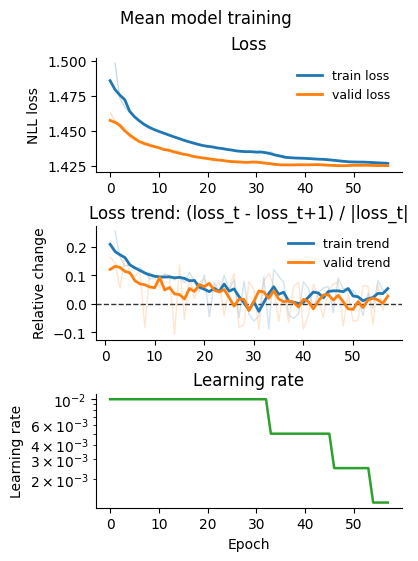

In [14]:
mean_trainer, mean_lit_model = build_lit_model(Conf, "conditional", "identity", True)
mean_trainer.fit(mean_lit_model, train_loader, valid_loader)
mean_metric = {k: float(v.detach().cpu()) for k, v in mean_trainer.callback_metrics.items() if torch.is_tensor(v)}
plot_training_history(mean_trainer.metric_history_callback.history, title='Mean model training', smooth_window=5)

In [15]:
# mean_cov_trainer, mean_cov_lit_model = build_lit_model(Conf, "conditional", "shared", True)
# mean_lit_model_state_dict = mean_lit_model.full_model.mean_model.state_dict()
# mean_cov_lit_model.full_model.mean_model.load_state_dict(mean_lit_model_state_dict, strict=True)
# for p in mean_cov_lit_model.full_model.mean_model.parameters():
#     p.requires_grad = False
# mean_cov_trainer.fit(mean_cov_lit_model, train_loader, valid_loader)
# mean_cov_history = {k: float(v.detach().cpu()) for k, v in mean_cov_trainer.callback_metrics.items() if torch.is_tensor(v)}
# plot_training_history(mean_cov_trainer.metric_history_callback.history, title='Mean + Cov model training', smooth_window=5)

In [48]:
torch.set_grad_enabled(True)

target_bin = 14
target_unit = 22


class ConditionalMeanTargetModel(torch.nn.Module):
    def __init__(self, lit_model, bin_idx, unit_idx):
        super().__init__()
        self.mean_model = lit_model.full_model.mean_model
        self.bin_idx = bin_idx
        self.unit_idx = unit_idx

    def forward(self, x_positionvars, x_densevars, x_sparsevars):
        x = (x_positionvars, x_densevars, x_sparsevars)
        mean = self.mean_model(x)
        return mean[:, self.bin_idx, self.unit_idx].unsqueeze(1)

target_model = ConditionalMeanTargetModel(mean_lit_model, bin_idx=target_bin, unit_idx=target_unit).to(device).eval()

for p in target_model.parameters():
    p.requires_grad_(False)

background = [train_dataset.x_position_vars.to(device), train_dataset.x_dense_vars.to(device), train_dataset.x_sparse_vars.to(device)]
X_explain = [valid_dataset.x_position_vars.to(device), valid_dataset.x_dense_vars.to(device), valid_dataset.x_sparse_vars.to(device)]

explainer = shap.GradientExplainer(target_model, background)
shap_values = explainer.shap_values(X_explain, nsamples=100)

In [49]:
trial_idx = 3

position_values = np.asarray(shap_values[0])[trial_idx].sum(axis=0).squeeze()
dense_values = np.asarray(shap_values[1])[trial_idx].squeeze()
sparse_values = np.asarray(shap_values[2])[trial_idx].squeeze()

values = np.concatenate([position_values, dense_values, sparse_values])

position_data = X_explain[0][trial_idx].mean(axis=0).detach().cpu().numpy()
dense_data = X_explain[1][trial_idx].detach().cpu().numpy()
feature_names = ["x", "y", "z", "motion", "tunp", "tslp", "rewrate", "rewratio", "rew", "choice", "last_choice"]

position_shap = np.asarray(shap_values[0]).squeeze(-1).sum(axis=1)
dense_shap = np.asarray(shap_values[1]).squeeze(-1)
sparse_shap = np.asarray(shap_values[2]).squeeze(-1)

values = np.concatenate([position_shap, dense_shap, sparse_shap], axis=1)

position_data = X_explain[0].detach().cpu().numpy().mean(axis=1)
dense_data = X_explain[1].detach().cpu().numpy()
sparse_data = X_explain[2].detach().cpu().numpy()

data = np.concatenate([position_data, dense_data, sparse_data], axis=1)

base_value = target_model(*background).mean().item()

explanation = shap.Explanation(values=values, base_values=np.full(len(values), base_value), data=data, feature_names=feature_names)

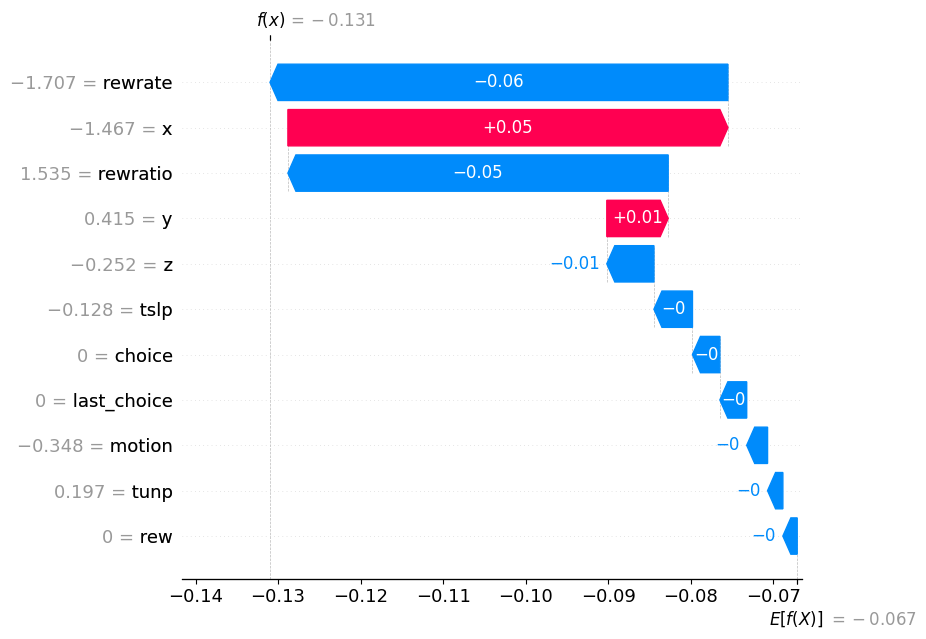

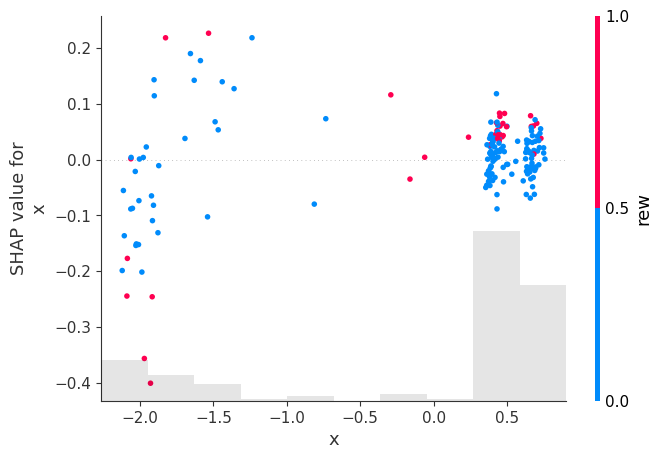

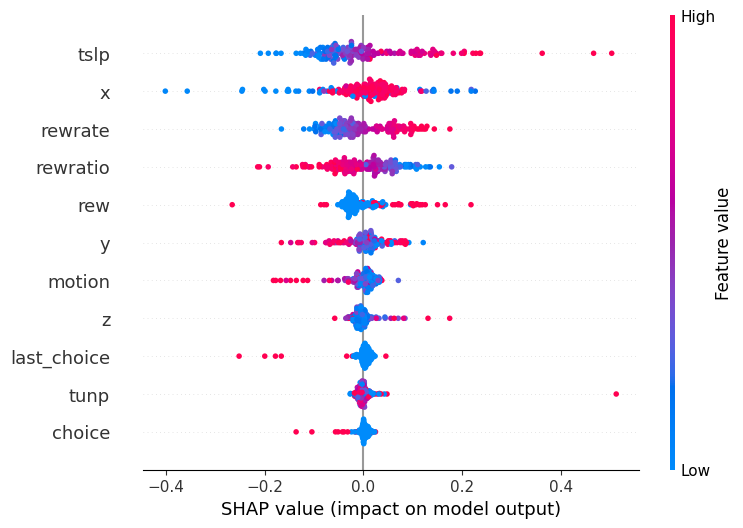

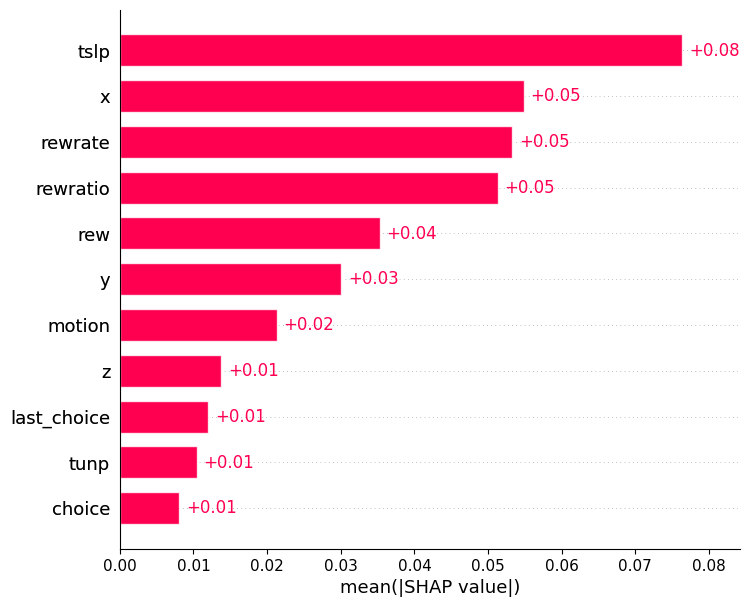

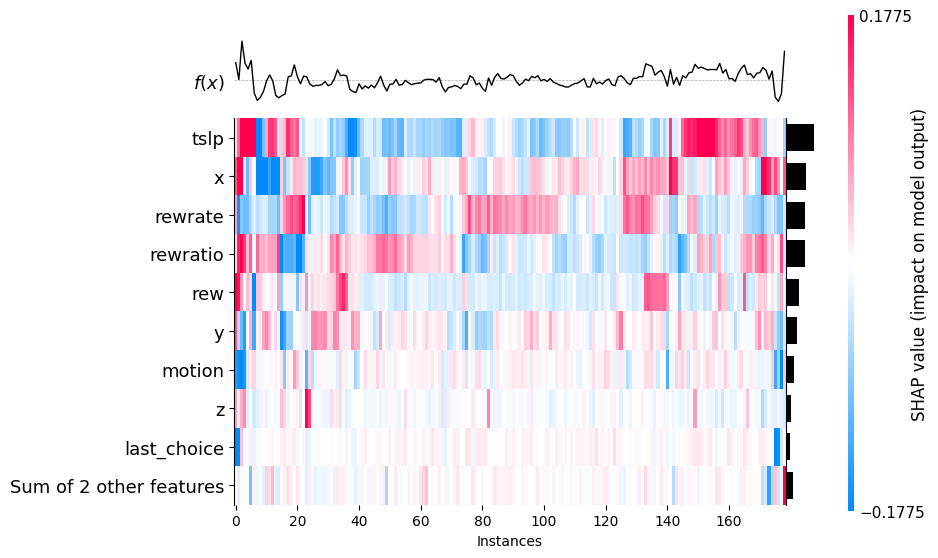

<Axes: xlabel='Instances'>

In [51]:
shap.plots.waterfall(explanation[trial_idx], max_display=len(feature_names))
shap.plots.scatter(explanation[:, "x"], color=explanation)
shap.plots.beeswarm(explanation, max_display=len(feature_names))
shap.plots.bar(explanation, max_display=len(feature_names))
shap.plots.heatmap(explanation)